<h3> Elementy statystyki opisowej i podstawy rachunku prawdopdobieństwa

In [12]:
options(repr.plot.width=8, repr.plot.height=6) #ustawia rozmiar obrazka

#### Małe podsumowanie dot. rozkładów

- r(norm, unif, ...) = generowanie liczb losowych
- p(norm, unif, ...) = wartość dystrybuanty
- d(norm, unif, ...) = wartość funkcji gęstości
- q(norm, unif, ...) = funkcja kwantylowa

In [4]:
rnorm(2) #2 liczby losowe z rozkładu N(0,1)

[1]  1.175474 -1.356211

In [3]:
pnorm(2) #P(X<=2)

[1] 0.9772499

In [5]:
dnorm(2) #f(2)

[1] 0.05399097

In [6]:
qnorm(0.977249868051821) #Rozwiązanie równania 0.977 = P(X <= t)

[1] 2

* Rozkład normalny

In [7]:
pnorm(0) #wartosc dystrybuanty rozkladu normalnego w punkcie 0, czyli F(0)

[1] 0.5

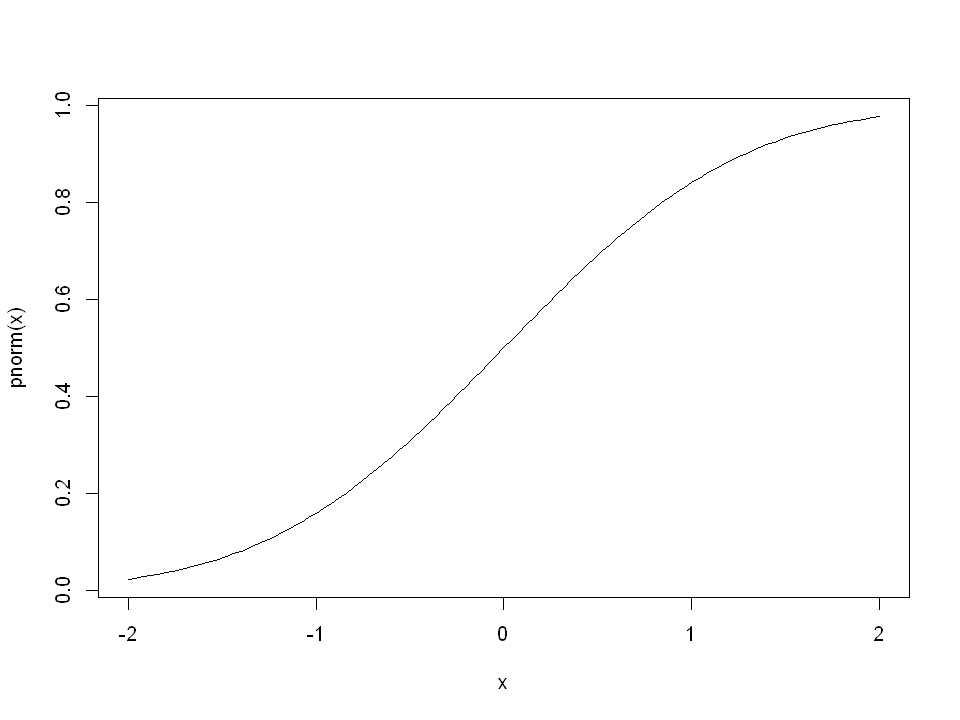

In [13]:
curve(pnorm, from=-2, to=2)

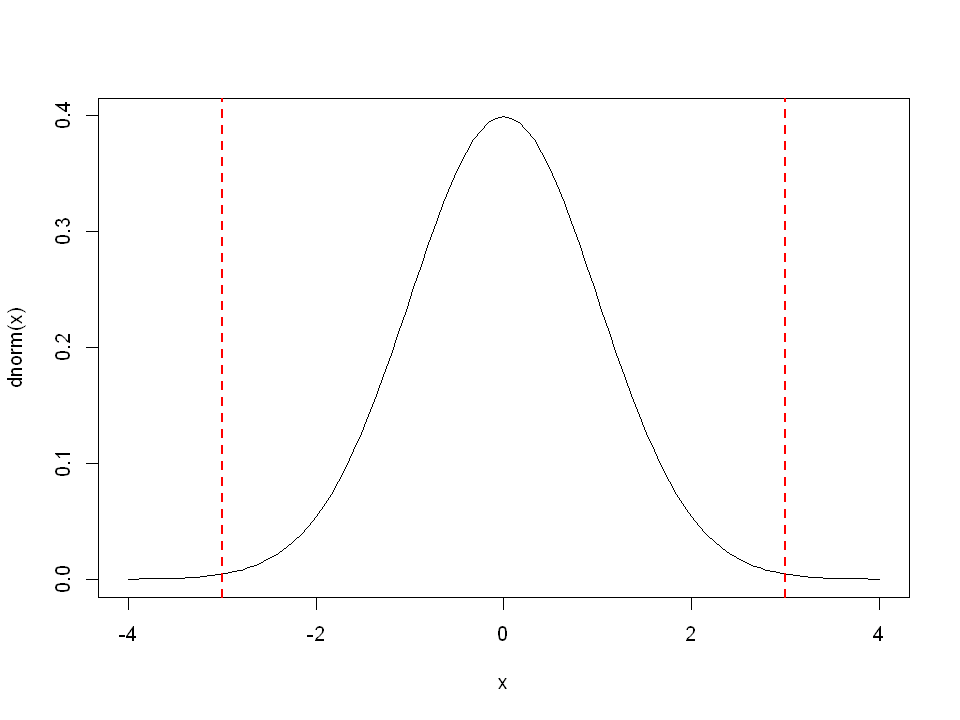

In [14]:
curve(dnorm, from=-4, to=4) #funkcja gęstosci rozkladu normalnego
abline(v=c(-3,3), col="red", lty=2, lwd=2) #pionowe linie

In [15]:
#regula 3 sigm:
pnorm(3)-pnorm(-3)

[1] 0.9973002

<h4> Pytanie: Jakie jest prawdopodbieństwo, że wylosujemy liczbę z przedziału $<-2,1>$, jeżeli losujemy z populacji opisanej przez rozkład normalny $N(0,1)$?

#### Skośność i kurtoza

In [16]:
library(moments)

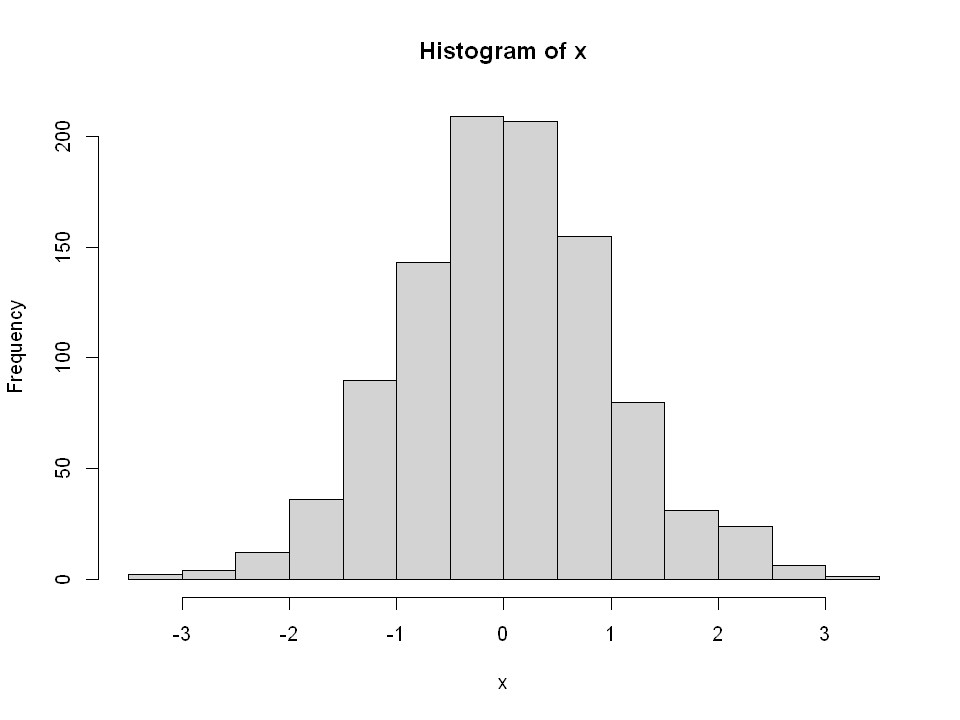

In [17]:
x = rnorm(1000) #generuje dane z rozkladu normalnegos
hist(x)

In [18]:
range(x); mean(x); median(x); sd(x); var(x)

[1] -3.346373  3.022544

[1] 0.01703077

[1] 0.0121977

[1] 0.9691926

[1] 0.9393343

In [19]:
quantile(x, 0.05); quantile(x, 0.50) #kwantyle 

5% 
-1.538062

50% 
0.0121977

In [20]:
skewness(x) #skośność

[1] 0.07177714

In [21]:
kurtosis(x) #kurtoza, dla rozkladu normalnego 3 

[1] 3.220259

<h4> Rozkład Weibull'a

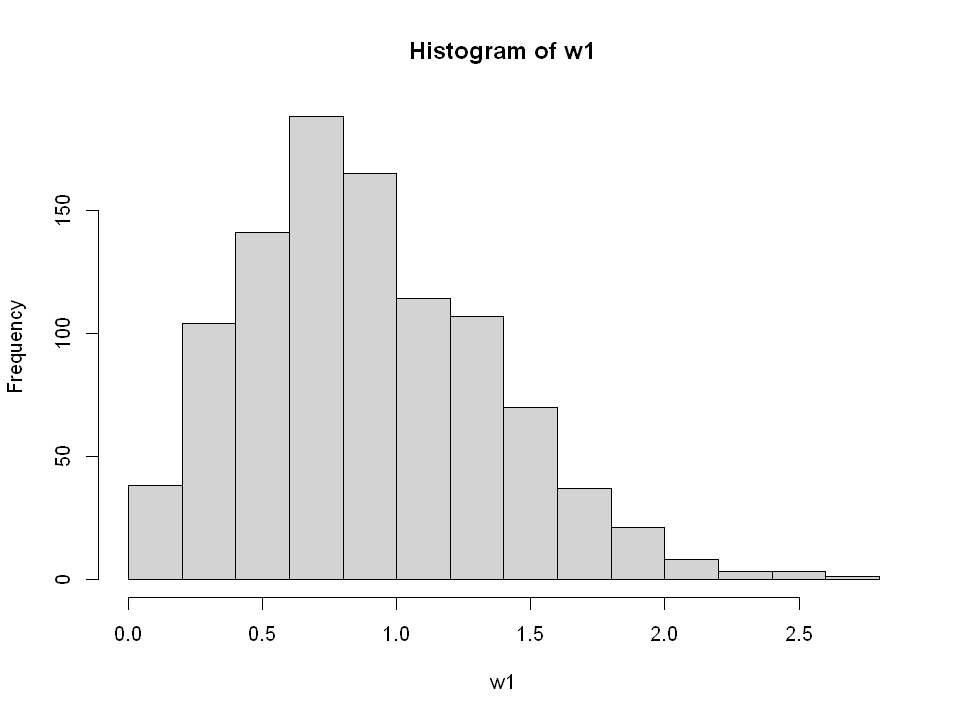

In [22]:
w1 = rweibull(1000, 2, 1)
hist(w1)

In [23]:
skewness(w1) #rozklad przesuniety w lewo - dodatnia skośność

[1] 0.596079

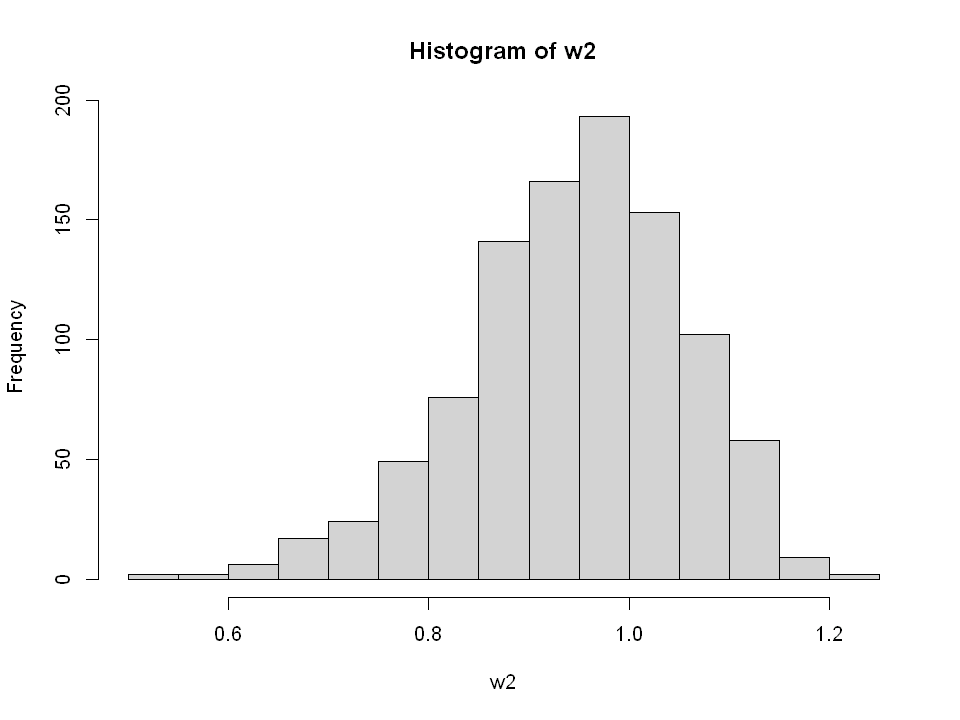

In [24]:
w2 = rweibull(1000, 10, 1)
hist(w2)

In [25]:
skewness(w2) #rozklad przesuniety w prawo - ujemna skośność

[1] -0.5045466

<h3> Prawa wielkich liczb

In [42]:
sample(1:6, 5, replace = TRUE) #5 rzutów kostką

[1] 6 5 4 4 2

In [43]:
mean(c(6,5,4,4,2)) #srednia z próby

[1] 4.2

In [38]:
replicate(3, mean(sample(1:6, 100, replace = TRUE))) #3 razy powtarzamy eksperyment -> rzucamy 100 razy i liczymy srednią

[1] 3.45 3.43 3.39 3.32 3.81

Przy odpowiednio dużej próbie pewne statystyki z próby są w przybliżeniu równe wartościom oczekiwanym odpowiednich zmiennych losowych, np. średnia z próby jest w przybliżeniu równa wartości oczekiwanej. $\overline{x} \approx EX$

<h4> Zadanie1: Wykonaj następujący eksperyment. Wylosuj kolejno 2, 3, 4.... oraz 1000 liczb losowych z rozkładu normalnego $N(2,3)$, każdorazowo licząc średnią i odchylenie z próby. Następnie narysuj dwa wykresy zależności: średniej od liczby wylosowanych liczb oraz odchylenia od liczby wylosowanych liczb.

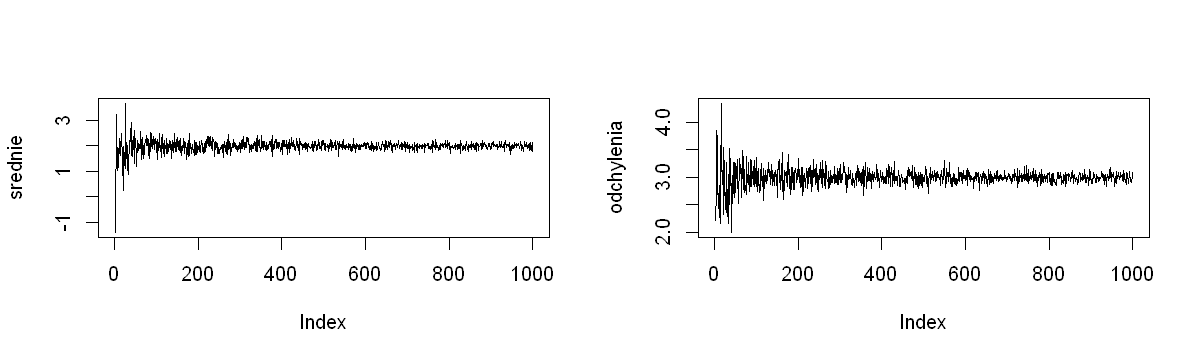

In [24]:
#oczekiwany wynik

<h4> Zadanie2: Wykonaj następujący eksperyment. Rzucamy kostką 1 raz, 2 razy,...., 1000 razy. Za każdym razem wyznaczamy częstości wystąpienia 1,2,3,4,5 oraz 6 oczek. Narysuj na jednym wykresie te częstości dla kolejnych rzutów. Podaj częstości dla ostatniej sytuacji.

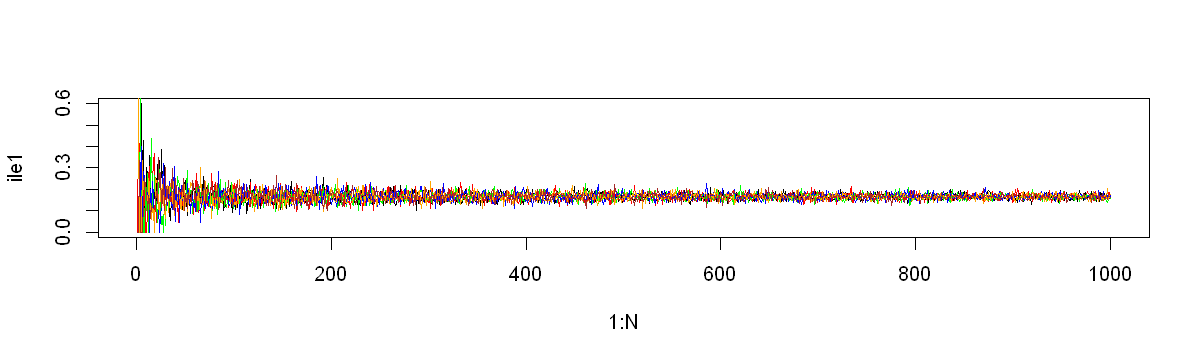

In [25]:
#oczekiwany wynik

<h4> Zadanie3: Jakie jest prawdopodobieństwo, że w rzucie 100 razy kostką do gry wylosujemy dokładnie 16 razy szóstkę? Zadanie rozwiąż na 2 sposoby:

- wyznacz dokładną wartość na podstawie rozkładu Bernoulliego (binom)
- wyznacz przybliżoną wartość poprzez symulację 100 tys razy tego eksperymentu.

<h4> Zadanie4: Mając początkowo $5$ zł wchodzimy z nimi do następującej gry.
    
- Do dyspozycji jest niesymetryczna moneta, na której z prawdopodobieństwem $p=0.6$ wypada orzeł.
- Rzucamy monetą, jeżeli wypadnie orzeł to otrzymujemy $1$ zł, w przeciwnym przypadku oddajemy $1$ zł.
- Grę kończymy, gdy osiągniemy $1000$ zł lub $0$ zł.

Jakie jest prawdopodobieństwo, że wygramy w takiej grze? Czy taka gra jest dla nas opłacalna? Ile należałoby mieć na początku, żeby na $99 \%$ być pewnym wygranej?

<h4> Centralne twierdzenie graniczne

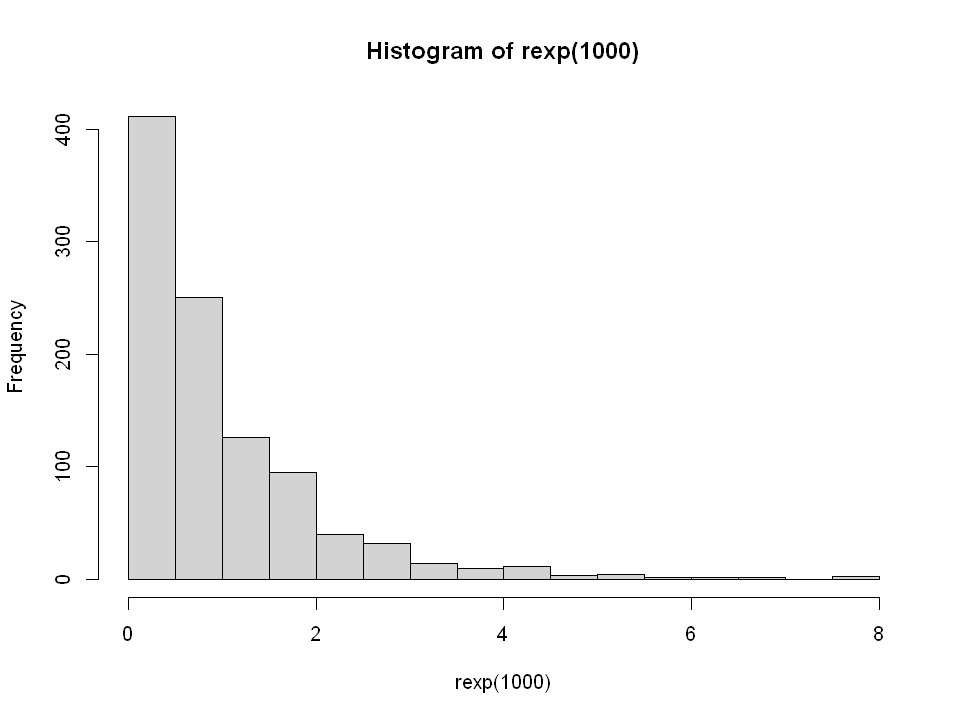

In [52]:
hist(rexp(1000))

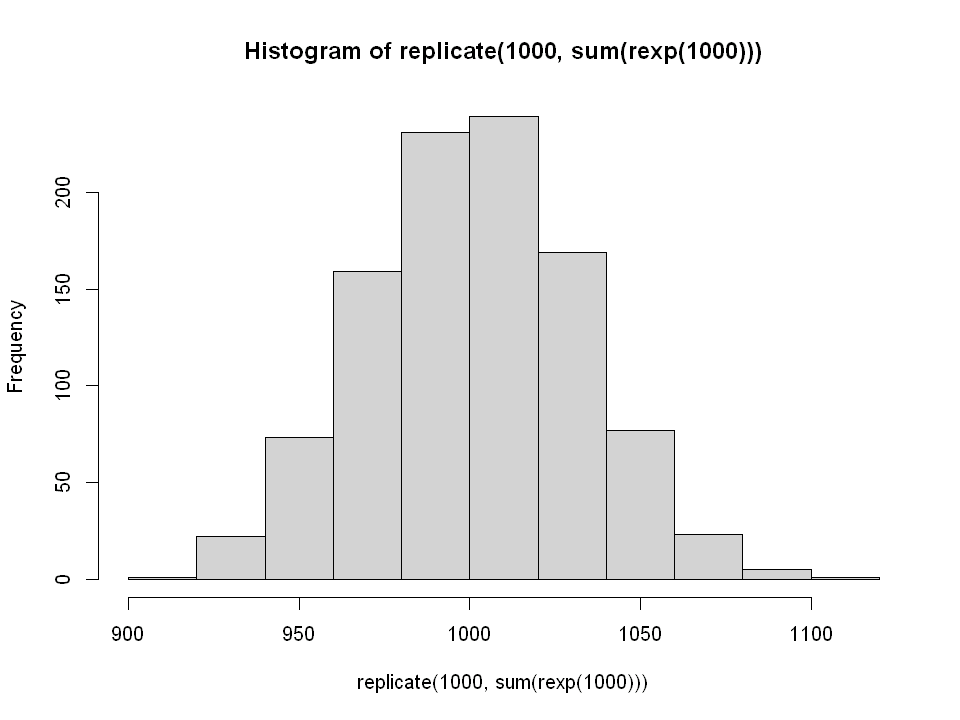

In [57]:
hist(replicate(1000, sum(rexp(1000))))

Jeżeli $X_1, X_2, ... X_n$ to ciąg niezależnych zmiennych losowych, z dowolnego (ale ustalonego) rozkładu o skończonej wariancji $\sigma^2$ i wartości oczekiwanej $\mu$, to 

$$\sum X_i  \rightarrow N(n\mu,\sigma \sqrt{n})$$ 

lub 

$$\frac{\sum X_i}{n} \rightarrow N(\mu,\frac{\sigma}{\sqrt{n}})$$ 

lub 

$$\frac{\sum X_i - n\mu}{\sigma \sqrt{n}} \rightarrow N(0,1)$$ 

lub 

$$\frac{\sum X_i/n - \mu}{\sigma /\sqrt{n}} \rightarrow N(0,1)$$

Przykład: Jakie jest (przybliżone) prawdopodobieństwo, że rzucając 1000 razy kostką do gry, suma oczek nie przekroczy 3550?

In [180]:
#symulacja
k = 10000
sum(replicate(k, ifelse(sum(sample(1:6, 1000, replace = TRUE))< 3550, 1, 0)))/k

[1] 0.8189

In [181]:
#CTW
x = 1:6 #wektor wartosci
p = rep(1/6, 6) #wektor prawdopodobieństw

ex = sum(p*x) #wartosc oczekiwana, pierwszy moment
ex2 = sum(p*x^2) #drugi moment
d2x = ex2 - ex^2 #wariancja
dx = sqrt(d2x) #odchylenie standardowe

print(ex) #wartość oczekiwana (mu)
print(dx) #odchylenie standardowe (sigma)



n = 1000
mu = ex
sigma = dx
cat("p =", pnorm(3550, n*ex, dx*sqrt(n)))

[1] 3.5
[1] 1.707825
p = 0.8227303

<h4> Zadanie5: Na statku jest 100 dorosłych osób. Waga w populacji opisana jest rozkładem $N(80, 20)$. Jakie jest prawdopodobieństwo, że waga tych osób nie przekroczy 8200 kg? Wykonaj zadanie na 2 sposoby:
 
- wykonując 100k symulacji (tej sytuacji) do oszacowania prawdopodobieństwa,
- wykorzystując Centralne Twierdzenie Graniczne
    
Czy założenie o normalności jest tutaj istotne?

<h4> Zadanie6: Zaprosiłeś na imprezę 64 osoby. Będziesz przygotowywał kanapki. Każdy gość zjada 0, 1 lub 2 kanapki z prawdopodobieństem 0.25, 0.50 i 0.25 odpowiednio. Ile co najmniej powinieneś przygotować kanapek aby na 95 % być pewnym, że wystarczy?

Założmy, że zadajemy ludziom pytanie na które mogą odpowiedzieć tylko na 2 sposoby (np. TAK lub NIE). Niech $T$ oznacza prawdopodobieństwo uzyskania odpowiedzi TAK, przy czym $T$ jest zmienną losową. Niech $p^*$ oznacza prawdopodobieństwo aproksymujące $ET$ (wartość oczekiwana $T$) na podstawie próby $n$- elementowej. Wtedy $$T \sim N(p^*, \sqrt{\frac{p^*(1-p^*)}{n}})$$

Dlaczego?

Dla zmienej $X$ z rozkładu dwupunktowego, dla której $P(X=1) = p$ oraz $P(X=0)=1-p$ mamy

$$\mu = 1 \cdot p+0 \cdot(1-p) = p$$ oraz $$\sigma = \sqrt{(1-p)^2 \cdot p+(0-p)^2 \cdot(1-p)} = ... = \sqrt{p(1-p)} $$ Rozważając ciąg zmiennych losowych $X_1, X_2,..., X_n$, z CTW wiemy, że

$$\frac{\sum X_i}{n} \rightarrow N(\mu,\frac{\sigma}{\sqrt{n}})$$ 

Oczywiście $T = \frac{\sum X_i}{n}$ (odsetek osób na TAK), natomiast $p^*$ jest estymatorem $p$ na podstawie próby. To już bezpośrednio prowadzi do powyższej własności.


<h4> Zadanie7: Aby ocenić szanse wyborcze partii $X$ przeprowadzono ankietę. W tym celu wybrano losowo 300 osób i zapytano o stostunek do partii $X$. 140 z nich odpowiedziało, że zagłosuje za partią $X$. Jakie jest prawdopodobieństwo, że w całej populacji ta partia uzyska mniej niż 43%?